In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Questão 1 -  EDA

### Parte 1

In [127]:
df = pd.read_csv('raw_data/orders.csv')
df.shape

(48998, 13)

In [91]:
# 3 intervalo de tempo entre o pedido mais antigo e o mais novo
from dateutil.relativedelta import relativedelta as rd
# coluna convertida em datetime
coluna_convertida = pd.to_datetime(df['created_at'], format='mixed')
#cálculo da data de pedido mais antiga e mais recente
inicio = coluna_convertida.min()
fim = coluna_convertida.max()
# relativedelta faz a operação de diferença entre as datas
diferenca = rd(fim, inicio)
# os valores são recuperados em uma string formatada para permitir melhor leitura
intervalo_formatado = f"{diferenca.years} anos, {diferenca.months} meses e {diferenca.days} dias"
# resultados mostrados na tela
print(inicio)
print(fim)
print(intervalo_formatado)



2020-01-01 01:19:28
2026-12-31 23:43:09
6 anos, 11 meses e 30 dias


Quantidade de Colunas = 13
Quantidade de Linhas = 48998
Intervalo de datas analisado (data mínima e máxima)

### Parte 2

Calcule esses valores da coluna 'total'  
1. valor mínimo
1. valor máximo
1. valor médio

In [92]:
# 1 - Valor mínimo
minimo = df['total'].min()
# 2 - Valor máximo
maximo = df['total'].max()
# 3 - Valor médio
medio = round(df['total'].mean(), 2)

print('Mínimo: R$', minimo)
print('Máximo: R$', maximo)
print('Médio: R$', medio)

Mínimo: R$ 32.62
Máximo: R$ 127262.02
Médio: R$ 28704.99


# Parte 3


In [ ]:
df.query("channel == 'ecommerce' and salesperson_id.isna()")

Porcentagem de valores nulos na coluna "salesperson_id": 49.25%


NaNs em "salesperson_id" são todos em registros em que o meio de venda é o ecommerce, ou seja, sem vendedor.

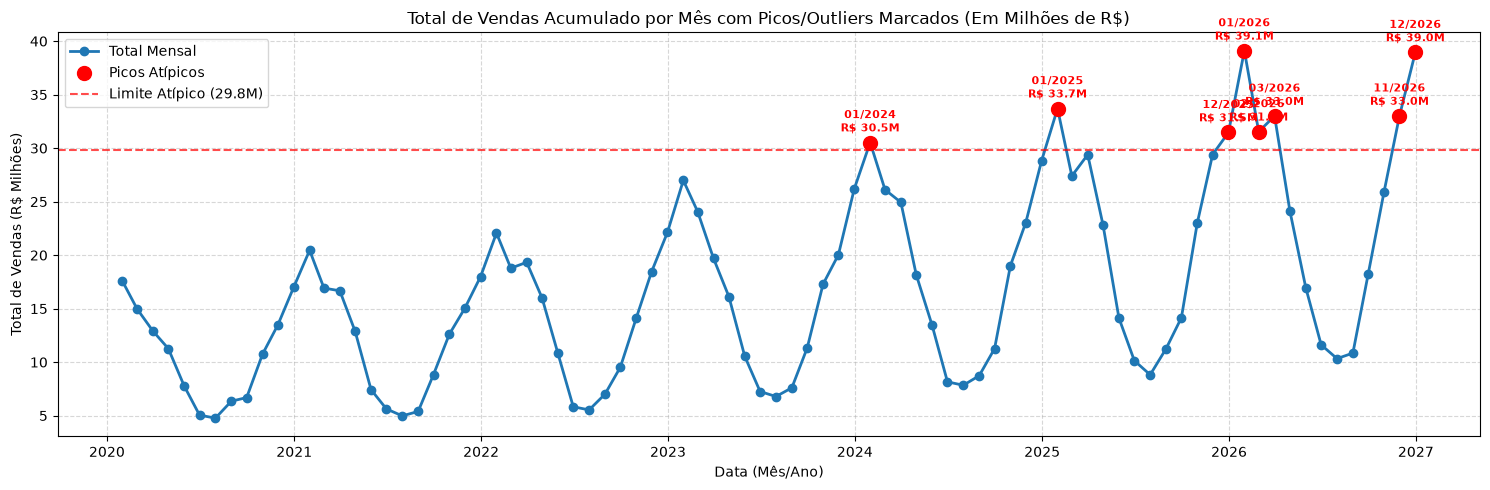

--- OUTLIERS / PICOS DE FATURAMENTO MENSAL ---
Data: 01/2024 | Valor: R$ 30.53M
Data: 01/2025 | Valor: R$ 33.70M
Data: 12/2025 | Valor: R$ 31.47M
Data: 01/2026 | Valor: R$ 39.11M
Data: 02/2026 | Valor: R$ 31.54M
Data: 03/2026 | Valor: R$ 33.00M
Data: 11/2026 | Valor: R$ 33.01M
Data: 12/2026 | Valor: R$ 38.96M


In [102]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Copiar e converter a coluna para datetime
df1 = df.copy()
df1['created_at'] = pd.to_datetime(df1['created_at'], format='mixed')

# 2. Agrupar o total acumulado mês a mês (usando 'M' para ampla compatibilidade)
df_mensal = df1.set_index('created_at').resample('ME')['total'].sum().reset_index()
df_mensal['total_milhoes'] = df_mensal['total'] / 1e6

# 3. Definir o limite de atipicidade/outliers (Média + 1.5 Desvio Padrão)
media = df_mensal['total_milhoes'].mean()
std = df_mensal['total_milhoes'].std()
limite = media + 1.5 * std

# 4. Filtrar os meses que são picos/outliers
outliers = df_mensal[df_mensal['total_milhoes'] > limite]

# 5. Plotar o gráfico de tendência mensal
plt.figure(figsize=(15, 5))
plt.plot(df_mensal['created_at'], df_mensal['total_milhoes'], marker='o', color='#1f77b4', linewidth=2, label='Total Mensal')

# MARCAR OS OUTLIERS EM VERMELHO
plt.scatter(outliers['created_at'], outliers['total_milhoes'], color='red', s=100, zorder=5, label='Picos Atípicos')

# Linha limite tracejada
plt.axhline(limite, color='red', linestyle='--', alpha=0.7, label=f'Limite Atípico ({limite:.1f}M)')

# Adicionar os rótulos automaticamente acima dos pontos (sem necessidade de offsets)
for _, row in outliers.iterrows():
    plt.annotate(
        f"{row['created_at'].strftime('%m/%Y')}\nR$ {row['total_milhoes']:.1f}M", 
        (row['created_at'], row['total_milhoes']),
        textcoords="offset points", 
        xytext=(0, 8), 
        ha='center',
        fontweight='bold',
        fontsize=8,
        color='red'
    )

# 6. Personalização do gráfico
plt.title('Total de Vendas Acumulado por Mês com Picos/Outliers Marcados (Em Milhões de R$)')
plt.xlabel('Data (Mês/Ano)')
plt.ylabel('Total de Vendas (R$ Milhões)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

# 7. Print detalhado dos outliers no console
print("--- OUTLIERS / PICOS DE FATURAMENTO MENSAL ---")
for _, row in outliers.iterrows():
    print(f"Data: {row['created_at'].strftime('%m/%Y')} | Valor: R$ {row['total_milhoes']:.2f}M")

Em meses como 11/2026 o aumento de faturamento pode ser por causa dos feriados prolongados (em 11/2026 são 2).
Se as pessoas vão ter mais dias livres para aproveitar o mar, então provavelmente haverá um aumento nas vendas da LH Nautical.

,id,order_number,channel,customer_id,salesperson_id,location_id,status,subtotal,discount_amount,total,placed_at,created_at,updated_at
0,1,SO-000001,ecommerce,1136,NaN,1,paid,323.34,35.57,287.77,2022-09-06 05:37:37,2022-09-06 05:37:37,2022-09-06 05:37:37
3,4,SO-000004,ecommerce,1123,NaN,3,paid,11095.62,665.74,10429.88,2024-03-12 20:39:36,2024-03-12 20:39:36,2024-03-12 20:39:36
5,6,SO-000006,ecommerce,117,NaN,1,paid,52683.82,0.00,52683.82,2026-08-28 17:50:58,2026-08-28 17:50:58,2026-08-28 17:50:58
6,7,SO-000007,ecommerce,489,NaN,1,paid,57270.24,0.00,57270.24,2026-10-29 08:56:37,2026-10-29 08:56:37,2026-10-29 08:56:37
8,10,SO-000010,ecommerce,947,NaN,6,cancelled,26444.39,0.00,26444.39,2022-04-13 16:10:59,2022-04-13 16:10:59,2022-04-13 16:10:59
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48989,49992,SO-049992,ecommerce,135,NaN,1,paid,34455.82,0.00,34455.82,2022-03-12 06:55:05,2022-03-12 06:55:05,2022-03-12 06:55:05
48992,49995,SO-049995,ecommerce,1929,NaN,4,confirmed,30467.43,0.00,30467.43,2025-02-01 14:35:32,2025-02-01 14:35:32,2025-02-01 14:35:32
48995,49998,SO-049998,ecommerce,1105,NaN,6,paid,12730.95,1527.71,11203.24,2024-06-02 19:10:21,2024-06-02 19:10:21,2024-06-02 19:10:21
48996,49999,SO-049999,ecommerce,1970,NaN,1,paid,27434.83,0.00,27434.83,2026-03-07 17:24:39,2026-03-07 17:24:39,2026-03-07 17:24:39
